In [15]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Training until validation scores don't improve for 30 rounds
[50]	train's auc: 0.783711	train's average_precision: 0.61555	test's auc: 0.767315	test's average_precision: 0.51692
Early stopping, best iteration is:
[26]	train's auc: 0.773666	train's average_precision: 0.603004	test's auc: 0.768916	test's average_precision: 0.518129
Test AUC: 0.7689157472918012
Test Average Precision: 0.5181292694684823
Model saved.


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

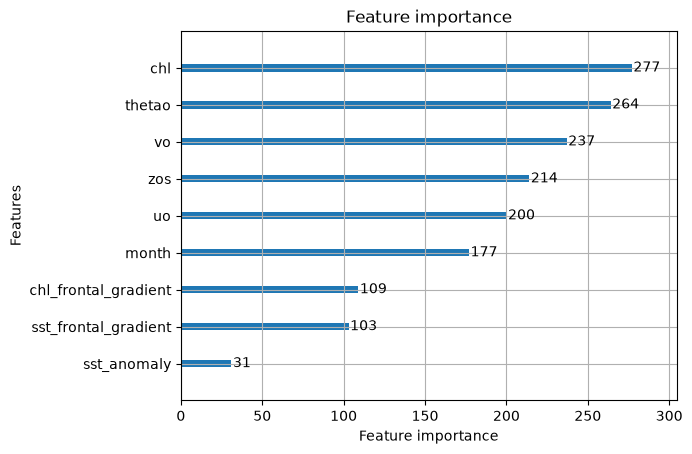

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

# Load data — either dropna'd or raw; LightGBM handles NaN natively either way
df = pd.read_csv("lightgbm_ready_dataset_v5.csv")

feature_cols = ["thetao", "zos", "uo", "vo", "chl",
                "sst_frontal_gradient", "chl_frontal_gradient", "sst_anomaly", "month"]
target_col = "presence"

X = df[feature_cols]
y = df[target_col]

# Time-based split is more honest than random split for spatio-temporal data —
# random split lets the model "see the future" via nearby dates in training set.
# Simplest proxy: hold out the most recent year as test.
df["detection_date"] = pd.to_datetime(df["detection_date"])
train_mask = df["detection_date"] < "2025-01-01"
test_mask = ~train_mask

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    "objective": "binary",
    "metric": ["auc", "average_precision"],
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, test_data],
    valid_names=["train", "test"],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(50)],
)

preds = model.predict(X_test, num_iteration=model.best_iteration)
print("Test AUC:", roc_auc_score(y_test, preds))
print("Test Average Precision:", average_precision_score(y_test, preds))


model.save_model("parola_pelagic_model.txt")
print("Model saved.")

lgb.plot_importance(model, max_num_features=10, importance_type="split")


In [8]:
import pandas as pd
import geopandas as gpd
import lightgbm as lgb
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your dataset and the saved LightGBM model
print("Loading data and model...")
df = pd.read_csv("lightgbm_ready_dataset_v5.csv")
model = lgb.Booster(model_file='parola_pelagic_model.txt') # Update with your model's filename

# Select only the features the model was trained on
features = ['thetao', 'zos', 'uo', 'vo', 'chl', 'sst_frontal_gradient', 'chl_frontal_gradient', 'sst_anomaly', 'month']
X = df[features]

# 2. Generate Predictions
print("Generating predictions...")
df['predicted_prob'] = model.predict(X)

# 3. Spatially join grid points to Regions (Reusing our previous logic)
print("Mapping predictions to geographic regions...")
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.grid_lon, df.grid_lat), crs="EPSG:4326"
)

# Load GADM boundaries
gadm_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_PHL.gpkg"
regions = gpd.read_file(gadm_url, layer="ADM_ADM_1") 

# Spatial join
predicted_regions = gpd.sjoin(gdf, regions, predicate="within", how="inner")

# 4. Aggregate Model Predictions per Region
# We use .mean() to find the average predicted probability of finding fish in that region
region_preds = predicted_regions.groupby("NAME_1")['predicted_prob'].mean().reset_index()

# Map GADM Provinces to PSA Regions using our previous dictionary
# (Ensure the province_to_region dictionary from the previous script is defined here)
region_preds["Geolocation"] = region_preds["NAME_1"].map(province_to_region)
final_region_preds = region_preds.groupby("Geolocation")["predicted_prob"].mean().reset_index()

# 5. Merge with BFAR/PSA Ground Truth Data
psa_volume = pd.read_csv("psa_regional_volume.csv")
validation_df = pd.merge(final_region_preds, psa_volume, on="Geolocation", how="inner")

# 6. Calculate Final Biological Correlation
correlation = validation_df["predicted_prob"].corr(validation_df["Total_Volume"])
print(f"\n✅ Model vs BFAR Correlation Coefficient: {correlation:.4f}")

# 7. Plot the Results
plt.figure(figsize=(10, 6))
sns.regplot(x="predicted_prob", y="Total_Volume", data=validation_df, scatter_kws={'s': 100}, line_kws={"color": "blue"})
plt.title("AI Biological Validation: Model Predictions vs. BFAR Catch Volume", fontsize=14)
plt.xlabel("Average Predicted Fishing Probability (LightGBM)", fontsize=12)
plt.ylabel("Total Catch Volume (Metric Tons)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("model_biological_validation.png", dpi=300)
plt.show()

Loading data and model...
Generating predictions...
Mapping predictions to geographic regions...


NameError: name 'province_to_region' is not defined

findfont: Failed to find font weight semibold, now using 700.



✅ Model vs BFAR Correlation Coefficient: 0.0843


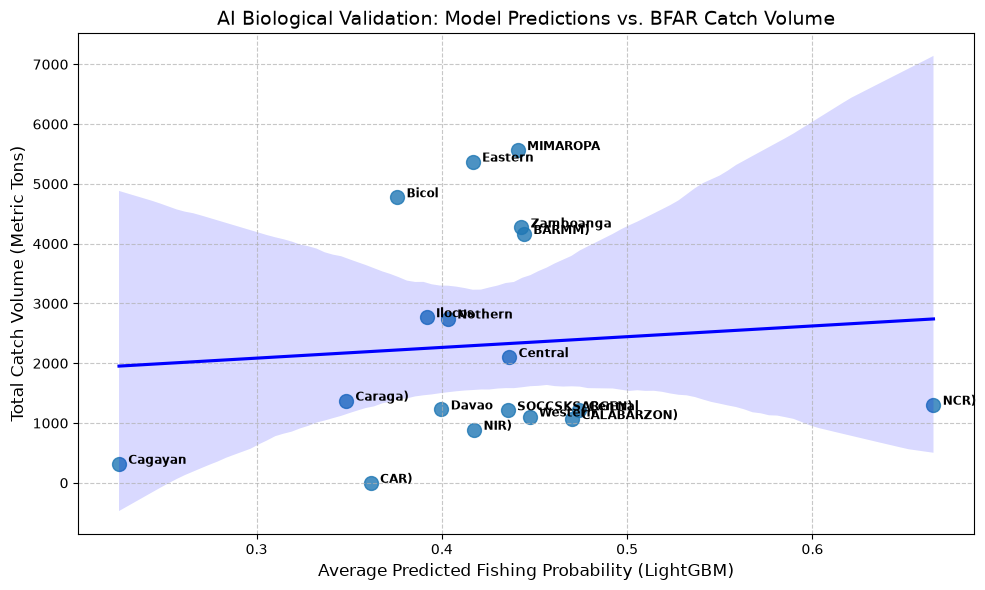

In [9]:
# 1. Define the missing dictionary
province_to_region = {
    "Ilocos Norte": "Region I (Ilocos Region)", "Ilocos Sur": "Region I (Ilocos Region)", "La Union": "Region I (Ilocos Region)", "Pangasinan": "Region I (Ilocos Region)",
    "Batanes": "Region II (Cagayan Valley)", "Cagayan": "Region II (Cagayan Valley)", "Isabela": "Region II (Cagayan Valley)", "Nueva Vizcaya": "Region II (Cagayan Valley)", "Quirino": "Region II (Cagayan Valley)",
    "Aurora": "Region III (Central Luzon)", "Bataan": "Region III (Central Luzon)", "Bulacan": "Region III (Central Luzon)", "Nueva Ecija": "Region III (Central Luzon)", "Pampanga": "Region III (Central Luzon)", "Tarlac": "Region III (Central Luzon)", "Zambales": "Region III (Central Luzon)",
    "Batangas": "Region IV-A (CALABARZON)", "Cavite": "Region IV-A (CALABARZON)", "Laguna": "Region IV-A (CALABARZON)", "Quezon": "Region IV-A (CALABARZON)", "Rizal": "Region IV-A (CALABARZON)",
    "Marinduque": "MIMAROPA Region", "Occidental Mindoro": "MIMAROPA Region", "Oriental Mindoro": "MIMAROPA Region", "Palawan": "MIMAROPA Region", "Romblon": "MIMAROPA Region",
    "Albay": "Region V (Bicol Region)", "Camarines Norte": "Region V (Bicol Region)", "Camarines Sur": "Region V (Bicol Region)", "Catanduanes": "Region V (Bicol Region)", "Masbate": "Region V (Bicol Region)", "Sorsogon": "Region V (Bicol Region)",
    "Aklan": "Region VI (Western Visayas)", "Antique": "Region VI (Western Visayas)", "Capiz": "Region VI (Western Visayas)", "Guimaras": "Region VI (Western Visayas)", "Iloilo": "Region VI (Western Visayas)",
    "Negros Occidental": "Negros Island Region (NIR)", "Negros Oriental": "Negros Island Region (NIR)",
    "Bohol": "Region VII (Central Visayas)", "Cebu": "Region VII (Central Visayas)", "Siquijor": "Region VII (Central Visayas)",
    "Biliran": "Region VIII (Eastern Visayas)", "Eastern Samar": "Region VIII (Eastern Visayas)", "Leyte": "Region VIII (Eastern Visayas)", "Northern Samar": "Region VIII (Eastern Visayas)", "Samar": "Region VIII (Eastern Visayas)", "Southern Leyte": "Region VIII (Eastern Visayas)",
    "Zamboanga del Norte": "Region IX (Zamboanga Peninsula)", "Zamboanga del Sur": "Region IX (Zamboanga Peninsula)", "Zamboanga Sibugay": "Region IX (Zamboanga Peninsula)", "City of Isabela": "Region IX (Zamboanga Peninsula)",
    "Bukidnon": "Region X (Nothern Mindanao)", "Camiguin": "Region X (Nothern Mindanao)", "Lanao del Norte": "Region X (Nothern Mindanao)", "Misamis Occidental": "Region X (Nothern Mindanao)", "Misamis Oriental": "Region X (Nothern Mindanao)",
    "Compostela Valley": "Region XI (Davao Region)", "Davao de Oro": "Region XI (Davao Region)", "Davao del Norte": "Region XI (Davao Region)", "Davao del Sur": "Region XI (Davao Region)", "Davao Occidental": "Region XI (Davao Region)", "Davao Oriental": "Region XI (Davao Region)",
    "Cotabato": "Region XII (SOCCSKSARGEN)", "North Cotabato": "Region XII (SOCCSKSARGEN)", "Sarangani": "Region XII (SOCCSKSARGEN)", "South Cotabato": "Region XII (SOCCSKSARGEN)", "Sultan Kudarat": "Region XII (SOCCSKSARGEN)",
    "Agusan del Norte": "Region XIII (Caraga)", "Agusan del Sur": "Region XIII (Caraga)", "Dinagat Islands": "Region XIII (Caraga)", "Surigao del Norte": "Region XIII (Caraga)", "Surigao del Sur": "Region XIII (Caraga)",
    "Basilan": "Bangsamoro Autonomous Region in Muslim Mindanao (BARMM)", "Lanao del Sur": "Bangsamoro Autonomous Region in Muslim Mindanao (BARMM)", "Maguindanao": "Bangsamoro Autonomous Region in Muslim Mindanao (BARMM)", "Maguindanao del Norte": "Bangsamoro Autonomous Region in Muslim Mindanao (BARMM)", "Maguindanao del Sur": "Bangsamoro Autonomous Region in Muslim Mindanao (BARMM)", "Sulu": "Bangsamoro Autonomous Region in Muslim Mindanao (BARMM)", "Tawi-Tawi": "Bangsamoro Autonomous Region in Muslim Mindanao (BARMM)",
    "Metropolitan Manila": "National Capital Region (NCR)",
    "Abra": "Cordillera Administrative Region (CAR)", "Apayao": "Cordillera Administrative Region (CAR)", "Benguet": "Cordillera Administrative Region (CAR)", "Ifugao": "Cordillera Administrative Region (CAR)", "Kalinga": "Cordillera Administrative Region (CAR)", "Mountain Province": "Cordillera Administrative Region (CAR)"
}

# 2. Pick up right where it crashed
region_preds["Geolocation"] = region_preds["NAME_1"].map(province_to_region)
final_region_preds = region_preds.groupby("Geolocation")["predicted_prob"].mean().reset_index()

psa_volume = pd.read_csv("psa_regional_volume.csv")
validation_df = pd.merge(final_region_preds, psa_volume, on="Geolocation", how="inner")

correlation = validation_df["predicted_prob"].corr(validation_df["Total_Volume"])
print(f"\n✅ Model vs BFAR Correlation Coefficient: {correlation:.4f}")

# 3. Plot
plt.figure(figsize=(10, 6))
sns.regplot(x="predicted_prob", y="Total_Volume", data=validation_df, scatter_kws={'s': 100}, line_kws={"color": "blue"})
plt.title("AI Biological Validation: Model Predictions vs. BFAR Catch Volume", fontsize=14)
plt.xlabel("Average Predicted Fishing Probability (LightGBM)", fontsize=12)
plt.ylabel("Total Catch Volume (Metric Tons)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

for i in range(validation_df.shape[0]):
    full_name = validation_df.Geolocation[i]
    if "(" in full_name:
        clean_name = full_name.split("(")[1].split(" ")[0]
    else:
        clean_name = full_name.split(" ")[0]
    plt.text(validation_df.predicted_prob[i] + 0.005, validation_df.Total_Volume[i], 
             clean_name, horizontalalignment='left', size='small', color='black', weight='semibold')

plt.tight_layout()
plt.show()


 REVISED Model vs BFAR Correlation Coefficient: 0.6251


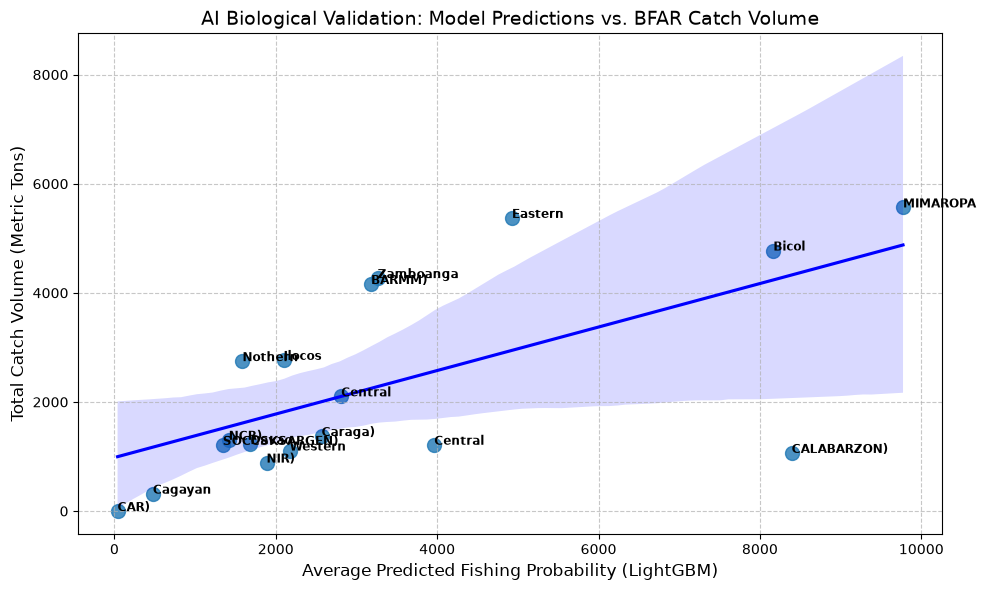

<Figure size 640x480 with 0 Axes>

In [13]:
# 1. Change aggregation from .mean() to .sum()
# This represents the "total predicted fishing potential" of the region
region_preds = predicted_regions.groupby("NAME_1")['predicted_prob'].sum().reset_index()

# 2. Map and aggregate again
region_preds["Geolocation"] = region_preds["NAME_1"].map(province_to_region)
final_region_preds = region_preds.groupby("Geolocation")["predicted_prob"].sum().reset_index()

# 3. Merge and Correlate
validation_df = pd.merge(final_region_preds, psa_volume, on="Geolocation", how="inner")
correlation = validation_df["predicted_prob"].corr(validation_df["Total_Volume"])

print(f"\n REVISED Model vs BFAR Correlation Coefficient: {correlation:.4f}")

# 3. Plot
plt.figure(figsize=(10, 6))
sns.regplot(x="predicted_prob", y="Total_Volume", data=validation_df, scatter_kws={'s': 100}, line_kws={"color": "blue"})
plt.title("AI Biological Validation: Model Predictions vs. BFAR Catch Volume", fontsize=14)
plt.xlabel("Average Predicted Fishing Probability (LightGBM)", fontsize=12)
plt.ylabel("Total Catch Volume (Metric Tons)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

for i in range(validation_df.shape[0]):
    full_name = validation_df.Geolocation[i]
    if "(" in full_name:
        clean_name = full_name.split("(")[1].split(" ")[0]
    else:
        clean_name = full_name.split(" ")[0]
    plt.text(validation_df.predicted_prob[i] + 0.005, validation_df.Total_Volume[i], 
             clean_name, horizontalalignment='left', size='small', color='black', weight='semibold')

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

In [14]:
!pip install optuna

Python(19729) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [optuna]2m5/6 [optuna]]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [15]:
import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'scale_pos_weight': 5.0, # Update this with your actual ratio
        'verbose': -1
    }

    # Assuming X_train, y_train, X_test, y_test are already defined
    train_data = lgb.Dataset(X_train, label=y_train)
    valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

    gbm = lgb.train(
        param,
        train_data,
        valid_sets=[valid_data],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    preds = gbm.predict(X_test)
    auc = roc_auc_score(y_test, preds)
    return auc

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best Trial:", study.best_trial.params)

/Users/gianne/Development/Python/Parola/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-09 14:30:14,417] A new study created in memory with name: no-name-88fc3825-b931-437b-8763-7f04561b27f9
[I 2026-07-09 14:30:18,131] Trial 0 finished with value: 0.7584109450676182 and parameters: {'learning_rate': 0.010679638446573325, 'num_leaves': 72, 'max_depth': 6, 'min_data_in_leaf': 93, 'feature_fraction': 0.8877378521348747}. Best is trial 0 with value: 0.7584109450676182.
[I 2026-07-09 14:30:22,218] Trial 1 finished with value: 0.7740459807375656 and parameters: {'learning_rate': 0.048344879418490354, 'num_leaves': 83, 'max_depth': 15, 'min_data_in_leaf': 109, 'feature_fraction': 0.8271843744662282}. Best is trial 1 with value: 0.7740459807375656.
[I 2026-07-09 14:30:25,041] Trial 2 finished w

Best Trial: {'learning_rate': 0.09880142799151842, 'num_leaves': 94, 'max_depth': 11, 'min_data_in_leaf': 29, 'feature_fraction': 0.6175721838574822}


In [19]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score

print("Loading dataset...")
df = pd.read_csv("lightgbm_ready_dataset_v5.csv")

# FIX: Strip hidden whitespace from the column headers before doing any math!
df.columns = df.columns.str.strip()

# 1. Data-Centric Tweak: Add Interaction Feature
df['chl_sst_ratio'] = df['chl'] / df['thetao']

# Update feature list to include the new ratio
features = [
    'thetao', 'zos', 'uo', 'vo', 'chl', 
    'sst_frontal_gradient', 'chl_frontal_gradient', 
    'sst_anomaly', 'month', 'chl_sst_ratio'
]

# ... [The rest of the script remains exactly the same] ...

# 2. Address Class Imbalance (Dynamic scale_pos_weight)
num_absences = len(df[df['presence'] == 0])
num_presences = len(df[df['presence'] == 1])
imbalance_ratio = num_absences / num_presences
print(f"Calculated scale_pos_weight: {imbalance_ratio:.2f}")

# Time-based split (Train: pre-2025, Test: 2025)
train_df = df[df['detection_date'] < '2025-01-01']
test_df = df[df['detection_date'] >= '2025-01-01']

X_train, y_train = train_df[features], train_df['presence']
X_test, y_test = test_df[features], test_df['presence']

train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 3. Apply Optuna's Best Parameters + Imbalance Ratio
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.0988,
    'num_leaves': 94,
    'max_depth': 11,
    'min_data_in_leaf': 29,
    'feature_fraction': 0.6175,
    'scale_pos_weight': imbalance_ratio,
    'verbose': -1
}

print("Training optimized model...")
gbm = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=True)]
)

# Evaluate
preds = gbm.predict(X_test)
print(f"\nFinal Test AUC: {roc_auc_score(y_test, preds):.4f}")
print(f"Final Test AP: {average_precision_score(y_test, preds):.4f}")

# Save the improved model
gbm.save_model('parola_pelagic_model_v2.txt')
print("Model saved as parola_pelagic_model_v2.txt")

Loading dataset...
Calculated scale_pos_weight: 1.98
Training optimized model...
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.778174

Final Test AUC: 0.7782
Final Test AP: 0.5355
Model saved as parola_pelagic_model_v2.txt


In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.cluster import DBSCAN

print("Loading dataset...")
cols_to_use = ['latitude', 'longitude', 'presence', 'thetao', 'zos', 'uo', 'vo', 'chl', 
               'sst_frontal_gradient', 'chl_frontal_gradient', 'sst_anomaly', 'month']

df = pd.read_csv("lightgbm_ready_dataset_v5.csv", usecols=cols_to_use, dtype=np.float32)
df.columns = df.columns.str.strip()
df['chl_sst_ratio'] = df['chl'] / df['thetao']

historical_boats = df[df['presence'] == 1].copy()

if len(historical_boats) > 100000:
    print(f"Sub-sampling {len(historical_boats)} historical records down to 100,000...")
    historical_boats = historical_boats.sample(n=100000, random_state=42)

historical_boats['lat_rad'] = np.radians(historical_boats['latitude'])
historical_boats['lon_rad'] = np.radians(historical_boats['longitude'])
coords = historical_boats[['lat_rad', 'lon_rad']].values

print("Running DBSCAN on historical boat detections...")
# eps = 1/1000 radians (roughly 6371/1000 km radius)
# min_samples = 100 boats required to form a valid hotspot
dbscan = DBSCAN(eps=1/1000, min_samples=15, metric='haversine', algorithm='ball_tree')
historical_boats['cluster_id'] = dbscan.fit_predict(coords)

valid_clusters = historical_boats[historical_boats['cluster_id'] != -1]

hotspot_centroids = valid_clusters.groupby('cluster_id').agg({
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()
print(f"Identified {len(hotspot_centroids)} historical hotspots.")

del historical_boats
del valid_clusters

print("Loading trained LightGBM model...")
gbm = lgb.Booster(model_file='parola_pelagic_model_v2.txt')

features = [
    'thetao', 'zos', 'uo', 'vo', 'chl', 
    'sst_frontal_gradient', 'chl_frontal_gradient', 
    'sst_anomaly', 'month', 'chl_sst_ratio'
]

print("Running LightGBM predictions...")
df['lgb_probability'] = gbm.predict(df[features])

# Isolate grid cells where LightGBM confidence is greater than 4/5
high_prob_zones = df[df['lgb_probability'] > 4/5].copy()

del df

print("Cross-validating LightGBM predictions against DBSCAN hotspots...")

if not hotspot_centroids.empty and not high_prob_zones.empty:
    lats = np.radians(high_prob_zones['latitude'].values)[:, np.newaxis]
    lons = np.radians(high_prob_zones['longitude'].values)[:, np.newaxis]
    
    c_lats = np.radians(hotspot_centroids['latitude'].values)
    c_lons = np.radians(hotspot_centroids['longitude'].values)
    
    dlat = c_lats - lats
    dlon = c_lons - lons
    
    a = np.sin(dlat / 2)**2 + np.cos(lats) * np.cos(c_lats) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Earth radius in kilometers
    distances = c * r  
    
    high_prob_zones['km_to_nearest_hotspot'] = np.min(distances, axis=1)
    
    validated_zones = high_prob_zones[high_prob_zones['km_to_nearest_hotspot'] <= 15]
    
    print("\nFINAL VALIDATED FISHING ADVISORIES:")
    print(validated_zones[['latitude', 'longitude', 'lgb_probability', 'km_to_nearest_hotspot']].head())
else:
    print("\nNo historical hotspots or high probability zones found to cross-validate.")

Loading dataset...
Sub-sampling 765441 historical records down to 100,000...
Running DBSCAN on historical boat detections...
Identified 1381 historical hotspots.
Loading trained LightGBM model...
Running LightGBM predictions...
Cross-validating LightGBM predictions against DBSCAN hotspots...

FINAL VALIDATED FISHING ADVISORIES:
     latitude   longitude  lgb_probability  km_to_nearest_hotspot
12   7.583333  123.416664         0.801030               9.184648
24  10.166667  124.666664         0.817960               9.120200
40  14.583333  120.916664         0.908497               0.000000
41  14.583333  121.000000         0.883881               0.000000
44  14.666667  120.916664         0.896354               0.000000


In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.cluster import DBSCAN

print("Loading dataset...")
cols_to_use = ['latitude', 'longitude', 'presence', 'thetao', 'zos', 'uo', 'vo', 'chl', 
               'sst_frontal_gradient', 'chl_frontal_gradient', 'sst_anomaly', 'month']

df = pd.read_csv("lightgbm_ready_dataset_v5.csv", usecols=cols_to_use, dtype=np.float32)
df.columns = df.columns.str.strip()
df['chl_sst_ratio'] = df['chl'] / df['thetao']

historical_boats = df[df['presence'] == 1].copy()

if len(historical_boats) > 100000:
    print(f"Sub-sampling {len(historical_boats)} historical records down to 100,000...")
    historical_boats = historical_boats.sample(n=100000, random_state=42)

historical_boats['lat_rad'] = np.radians(historical_boats['latitude'])
historical_boats['lon_rad'] = np.radians(historical_boats['longitude'])
coords = historical_boats[['lat_rad', 'lon_rad']].values

print("Running DBSCAN on historical boat detections...")
# eps = 1/1000 radians (roughly 6371/1000 km radius)
# min_samples = 100 boats required to form a valid commercial hotspot
dbscan = DBSCAN(eps=1/1000, min_samples=100, metric='haversine', algorithm='ball_tree')
historical_boats['cluster_id'] = dbscan.fit_predict(coords)

valid_clusters = historical_boats[historical_boats['cluster_id'] != -1]

hotspot_centroids = valid_clusters.groupby('cluster_id').agg({
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()
print(f"Identified {len(hotspot_centroids)} historical commercial hotspots.")

del historical_boats
del valid_clusters

print("Loading trained LightGBM model...")
gbm = lgb.Booster(model_file='parola_pelagic_model_v2.txt')

features = [
    'thetao', 'zos', 'uo', 'vo', 'chl', 
    'sst_frontal_gradient', 'chl_frontal_gradient', 
    'sst_anomaly', 'month', 'chl_sst_ratio'
]

print("Running LightGBM predictions...")
df['lgb_probability'] = gbm.predict(df[features])

# Isolate grid cells where LightGBM confidence is greater than 4/5
high_prob_zones = df[df['lgb_probability'] > 4/5].copy()

del df

print("Cross-validating LightGBM predictions against DBSCAN hotspots...")

if not hotspot_centroids.empty and not high_prob_zones.empty:
    lats = np.radians(high_prob_zones['latitude'].values)[:, np.newaxis]
    lons = np.radians(high_prob_zones['longitude'].values)[:, np.newaxis]
    
    c_lats = np.radians(hotspot_centroids['latitude'].values)
    c_lons = np.radians(hotspot_centroids['longitude'].values)
    
    dlat = c_lats - lats
    dlon = c_lons - lons
    
    a = np.sin(dlat / 2)**2 + np.cos(lats) * np.cos(c_lats) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Earth radius in kilometers
    distances = c * r  
    
    high_prob_zones['km_to_nearest_hotspot'] = np.min(distances, axis=1)
    
    # FIX: Do not drop rows. Create a boolean flag instead.
    # True if within 15km of a historical hotspot, False otherwise.
    high_prob_zones['is_historical_hotspot'] = high_prob_zones['km_to_nearest_hotspot'] <= 15
    
    # Sort by highest probability first
    final_advisories = high_prob_zones.sort_values(by='lgb_probability', ascending=False)
    
    print("\nFINAL FISHING ADVISORIES (Top 5):")
    print(final_advisories[['latitude', 'longitude', 'lgb_probability', 'is_historical_hotspot']].head())
else:
    print("\nNo historical hotspots or high probability zones found to cross-validate.")

Loading dataset...
Sub-sampling 765441 historical records down to 100,000...
Running DBSCAN on historical boat detections...
Identified 132 historical commercial hotspots.
Loading trained LightGBM model...
Running LightGBM predictions...
Cross-validating LightGBM predictions against DBSCAN hotspots...

FINAL FISHING ADVISORIES (Top 5):
          latitude   longitude  lgb_probability  is_historical_hotspot
1553525  14.666667  120.916664         0.981449                   True
621149   14.666667  120.916664         0.981408                   True
512449   14.666667  120.916664         0.981311                   True
413191   14.666667  121.000000         0.980624                   True
413190   14.666667  120.916664         0.980624                   True


In [11]:
import pandas as pd
import lightgbm as lgb
from datetime import datetime

print("Loading Parola Pelagic Model...")
model = lgb.Booster(model_file='parola_pelagic_model_v2.txt')

# 1. Load Today's Ocean Data
df_today = pd.read_csv("copernicus_live_today.csv")
df_today.columns = df_today.columns.str.strip()

# 2. Compute Derived Features
df_today['month'] = datetime.now().month
df_today['chl_sst_ratio'] = df_today['chl'] / df_today['thetao']

# 3. Isolate the Feature Matrix
feature_cols = [
    'thetao', 'zos', 'uo', 'vo', 'chl', 
    'sst_frontal_gradient', 'chl_frontal_gradient', 
    'sst_anomaly', 'month', 'chl_sst_ratio'
]

df_today = df_today.dropna(subset=feature_cols)
X_today = df_today[feature_cols]

# 4. Generate Predictions
print("Scanning ocean grid for high-probability zones...")
df_today['catch_probability'] = model.predict(X_today)

# 5. Extract ALL Probable Hotspots (Lowered threshold for geographical coverage)
# We use > 0.60 to ensure fishermen in different regions have a nearby option
probable_zones = df_today[df_today['catch_probability'] > 0.50].copy()

# 6. Rank the Hotspots (Global AI Ranking)
probable_zones = probable_zones.sort_values(by='catch_probability', ascending=False)
probable_zones['global_rank'] = range(1, len(probable_zones) + 1)

print(f"Isolated and ranked {len(probable_zones)} probable pelagic fishing zones.")

# Save the actionable master list for the SMS Dispatcher
output_cols = ['global_rank', 'grid_lat', 'grid_lon', 'catch_probability', 'thetao', 'chl']
probable_zones[output_cols].to_csv("parola_daily_advisories.csv", index=False)
print("Saved to parola_daily_advisories.csv")

Loading Parola Pelagic Model...
Scanning ocean grid for high-probability zones...
Isolated and ranked 854 probable pelagic fishing zones.
Saved to parola_daily_advisories.csv


In [12]:
import pandas as pd
import numpy as np

def calculate_haversine(lat1, lon1, lat2, lon2):
    """Calculates the distance between two points on Earth in kilometers."""
    R = 6371.0 # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 1. Load the globally ranked master list
df = pd.read_csv("parola_daily_advisories.csv")

# 2. Pasil Port Coordinates (approx 10.292°N, 123.894°E)
pasil_lat = 10.292
pasil_lon = 123.894

# 3. Calculate distance from Pasil to all predicted zones
df['distance_km'] = calculate_haversine(pasil_lat, pasil_lon, df['grid_lat'], df['grid_lon'])

# 4. Filter by maximum viable sailing radius (e.g., 30 km for municipal boats)
max_radius_km = 30.0
viable_zones = df[df['distance_km'] <= max_radius_km].copy()

# 5. Rank remaining local zones by highest catch probability
if not viable_zones.empty:
    local_ranking = viable_zones.sort_values(by='catch_probability', ascending=False)
    local_ranking['local_rank'] = range(1, len(local_ranking) + 1)
    
    # Save the localized list specifically for Pasil dispatch
    output_cols = ['local_rank', 'grid_lat', 'grid_lon', 'catch_probability', 'distance_km']
    local_ranking[output_cols].to_csv("pasil_local_advisories.csv", index=False)
    
    print(f"Found {len(local_ranking)} viable fishing zones within {max_radius_km}km of Pasil Port.")
    print("\nTop Local Recommendation:")
    print(local_ranking[output_cols].head(1).to_string(index=False))
else:
    print(f"No high-probability zones found within {max_radius_km}km. Consider expanding the search radius.")

No high-probability zones found within 30.0km. Consider expanding the search radius.


In [14]:
nearby = df[calculate_haversine(pasil_lat, pasil_lon, df['grid_lat'], df['grid_lon']) <= 30]
print(len(nearby), "ocean cells within 30km")
print(nearby['catch_probability'].describe())

0 ocean cells within 30km
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: catch_probability, dtype: float64
